# Exploratory Data Analysis (EDA)

In this analysis, I explore how food delivery demand changes over time and how it may be influenced by weather conditions.

The order dataset is combined with hourly weather data to analyze demand patterns alongside temperature and precipitation variables.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_orders = pd.read_csv("order_history_kaggle_data.csv")
df_weather = pd.read_excel("weather.xlsx")

## Data Preparation

Before starting the analysis, both datasets need to be cleaned and aligned.

The order timestamps are converted into datetime format and rounded to hourly values, since the weather data is recorded on an hourly basis.  
The same transformation is applied to the weather dataset to ensure both datasets share a consistent time structure.

To verify consistency, the date ranges of both datasets are checked before merging.

Finally, the datasets are merged on the datetime column to create a unified dataset for analysis.

In [7]:
# Orders datetime
df_orders["datetime"] = pd.to_datetime(
    df_orders["Order Placed At"],
    format="%I:%M %p, %B %d %Y",
    errors="coerce"
).dt.floor("h")

df_orders = df_orders.dropna(subset=["datetime"]).copy()

# Weather datetime
df_weather["datetime"] = pd.to_datetime(
    df_weather["datetime"],
    errors="coerce"
).dt.floor("h")

df_weather = df_weather.dropna(subset=["datetime"]).copy()

# Hourly order count
orders_per_hour = df_orders.groupby("datetime").size().reset_index(name="order_count")

# Check date ranges before merge
print("Orders:", orders_per_hour["datetime"].min(), "→", orders_per_hour["datetime"].max())
print("Weather:", df_weather["datetime"].min(), "→", df_weather["datetime"].max())

# Merge datasets
df_merged = pd.merge(
    orders_per_hour,
    df_weather,
    on="datetime",
    how="inner"
)

df_merged.head()

Orders: 2024-09-01 00:00:00 → 2025-01-31 23:00:00
Weather: 2024-09-01 00:00:00 → 2025-01-31 23:00:00


,datetime,order_count,time,temperature_2m,precipitation
0,2024-09-01 00:00:00,1,2024-09-01T00:00,25.9,0.0
1,2024-09-01 01:00:00,2,2024-09-01T01:00,27.0,0.0
2,2024-09-01 02:00:00,7,2024-09-01T02:00,28.1,0.0
3,2024-09-01 03:00:00,5,2024-09-01T03:00,29.5,0.0
4,2024-09-01 11:00:00,3,2024-09-01T11:00,33.2,0.0


## General Overview

In this section, I first examine the overall structure of the merged dataset.  
This helps to understand the size and general characteristics of the data.

In [8]:
# Dataset size
print("Dataset shape:", df_merged.shape)

# Date range
print("Date range:", df_merged["datetime"].min(), "→", df_merged["datetime"].max())

Dataset shape: (2555, 5)
Date range: 2024-09-01 00:00:00 → 2025-01-31 23:00:00


### Data Quality Check

Next, I check for missing values and review summary statistics.

This step ensures that the dataset is clean and suitable for further analysis.

In [14]:
# Missing values
print("\nMissing values:\n", df_merged.isnull().sum())

# Summary statistics
df_merged.select_dtypes(include='number').describe()


Missing values:
 datetime          0
order_count       0
temperature_2m    0
precipitation     0
dtype: int64


,order_count,temperature_2m,precipitation
count,2555.000000,2555.000000,2555.000000
mean,8.344814,19.523640,0.124501
std,6.978578,6.283644,0.877846
min,1.000000,7.000000,0.000000
25%,4.000000,13.900000,0.000000
50%,7.000000,20.200000,0.000000
75%,11.000000,24.900000,0.000000
max,51.000000,33.500000,16.100000


## Time-Based Analysis

Customer demand often follows daily and weekly patterns.  
In this section, I analyze how order volume changes by hour and by day of the week.

### Hourly Order Pattern

In this section, I analyze how order demand changes throughout the day.

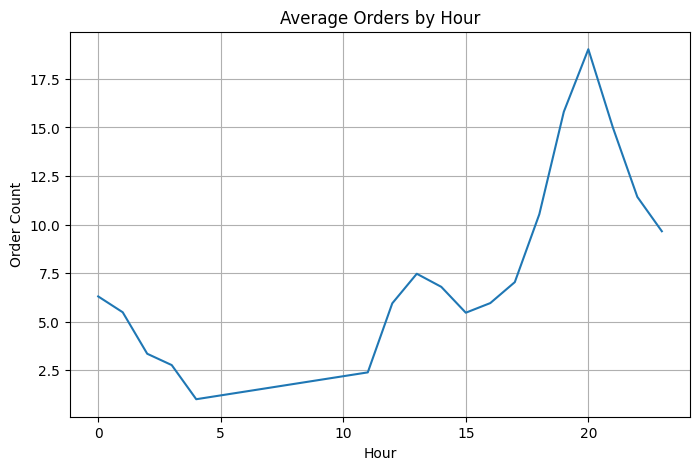

In [15]:
df_merged["hour"] = df_merged["datetime"].dt.hour

plt.figure(figsize=(8,5))
df_merged.groupby("hour")["order_count"].mean().plot()
plt.title("Average Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Order Count")
plt.grid(True)
plt.show()



The hourly analysis shows that order demand varies significantly throughout the day.

There are clear peaks during certain hours, which likely correspond to typical meal times such as lunch and dinner.

This indicates that customer behavior is strongly driven by daily routines.

### Daily Order Pattern

In this section, I examine how order demand changes across different days of the week.

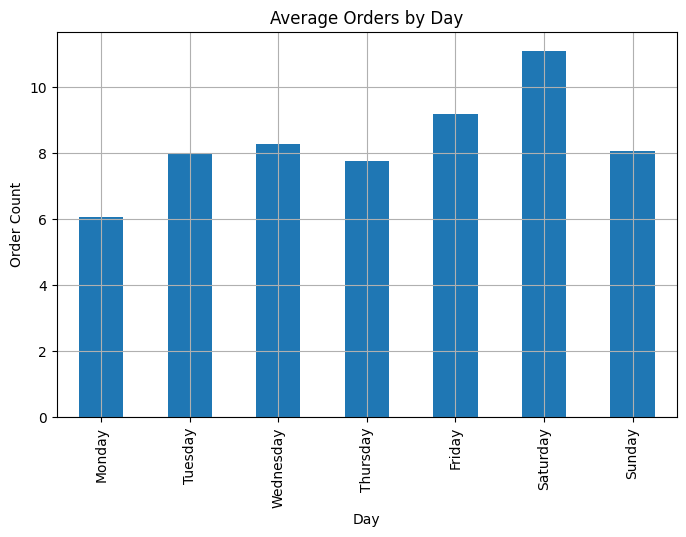

In [16]:
df_merged["day_name"] = df_merged["datetime"].dt.day_name()

plt.figure(figsize=(8,5))
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df_merged.groupby("day_name")["order_count"].mean().reindex(order_days).plot(kind="bar")
plt.title("Average Orders by Day")
plt.xlabel("Day")
plt.ylabel("Order Count")
plt.grid(True)
plt.show()


The daily analysis shows that order demand is not evenly distributed across the week.

Some days have higher average demand, which may be linked to lifestyle patterns such as weekends or reduced cooking at home.

This suggests that both time of day and day of the week influence customer behavior.

## Weather Impact on Demand

Weather conditions may influence customer behavior.  
In this section, I explore how temperature and precipitation relate to order volume.

### Temperature vs Order Demand

In this section, I explore how temperature relates to food delivery demand.

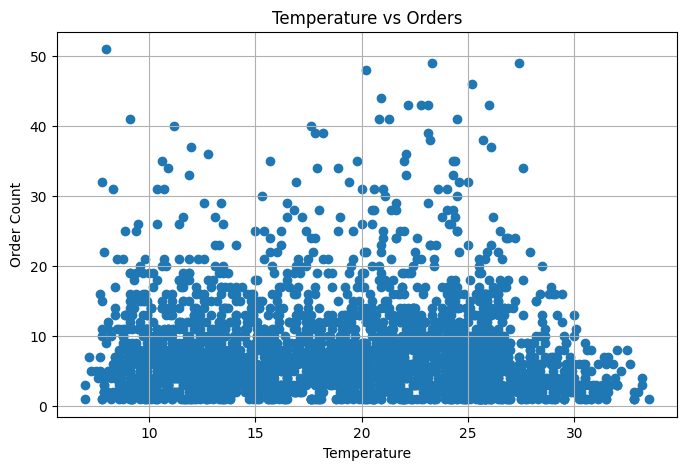

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df_merged["temperature_2m"], df_merged["order_count"])
plt.title("Temperature vs Orders")
plt.xlabel("Temperature")
plt.ylabel("Order Count")
plt.grid(True)
plt.show()


The scatter plot does not show a strong relationship between temperature and order volume.

Although there are slight variations, demand appears relatively stable across different temperature levels.

This suggests that temperature alone may not significantly influence customer ordering behavior.

### Precipitation vs Order Demand

In this section, I examine whether rainfall has an impact on food delivery demand.

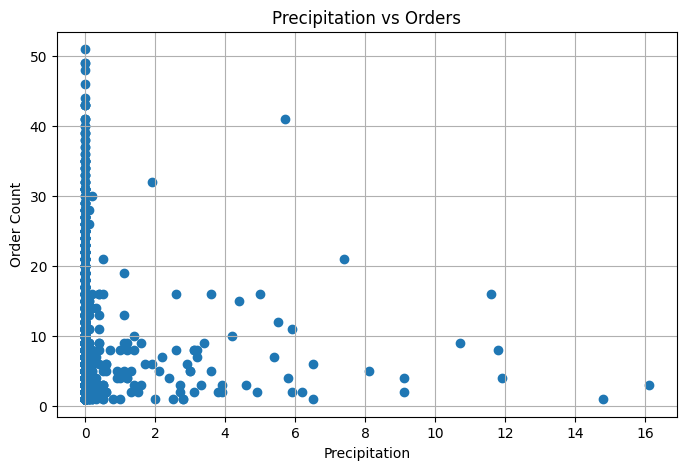

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df_merged["precipitation"], df_merged["order_count"])
plt.title("Precipitation vs Orders")
plt.xlabel("Precipitation")
plt.ylabel("Order Count")
plt.grid(True)
plt.show()


The relationship between precipitation and order volume is not clearly visible in the data.

Even though it might be expected that rainfall increases demand, the scatter plot does not show a strong pattern.

This indicates that precipitation alone may not be a major driver of food delivery demand.

## Conclusion

The analysis shows that food delivery demand varies across different hours and days.

Weather variables such as temperature and precipitation may also have an impact, although the relationship is not immediately obvious from visual inspection.

These findings provide a foundation for further statistical analysis, which will be explored in the next stage of the project.